# 05 · Watch an investigation happen

Created by Shivam Bharadwaj · [Build GoalLab](../README.md) · [Protocol](../PROTOCOL.md)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/projects/goallab/build-goallab/notebooks/05_investigation_demo.ipynb)

**Question:** can a learner explain the agent's decision from what it actually inspected?

You will run a trained controller, visualize evidence and contradictions, export the interactive explorer, and distinguish saved playback from live tool execution. The demo should make the task understandable before asking anyone to interpret a score.

**Prerequisites:** Build GoalLab lab 01. **Outcome:** an inspectable investigation and a runnable demo.

![The investigation loop and independent final evaluation](../architecture.svg)

**Run:** restart the kernel and run all cells. Each lab is independent. The default uses CPU, no API key, and no pretrained-model download. Colab runs need the published repository revision. Code is MIT; educational text and plots are CC BY 4.0.

In [1]:
import sys, subprocess, tempfile, json
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p/'rl_course/goallab_benchmark.py').exists()), None)
if ROOT is None and IN_COLAB:
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git','clone','--depth','1','https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git',str(ROOT)],check=True)
    subprocess.run([sys.executable,'-m','pip','install','-q','numpy','matplotlib','torch'],check=True)
if ROOT is None or not (ROOT/'rl_course/goallab_benchmark.py').exists():
    raise FileNotFoundError('Use the full repository revision containing GoalLab-v2.')
sys.path.insert(0,str(ROOT))
import numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import display, Markdown
from rl_course import goallab_benchmark as g, goallab_training as train
torch.set_num_threads(2)
ARTIFACTS = Path(tempfile.mkdtemp(prefix='goallab-lab-'))
plt.rcParams.update({'figure.figsize':(9,4),'figure.facecolor':'#f5f1e8','axes.facecolor':'#f5f1e8',
    'axes.spines.top':False,'axes.spines.right':False,'axes.prop_cycle':plt.cycler(color=['#af824a','#657951','#87708c','#292332'])})
def table(headers, rows):
    display(Markdown('| '+' | '.join(headers)+' |\n|'+'|'.join(['---']*len(headers))+'|\n'+
        '\n'.join('| '+' | '.join(str(v) for v in row)+' |' for row in rows)))
print(g.VERSION, '| Torch',torch.__version__, '| device: CPU | artifacts:',ARTIFACTS)

GoalLab-v2 | Torch 2.11.0+cu130 | device: CPU | artifacts: /tmp/goallab-lab-_l_lfztc


## 1. Load a reproducible small controller

The included checkpoint is the first reference seed, not a selected best seed. Loading uses PyTorch's weights-only mode. The final evaluator remains outside the policy.

In [2]:
saved=torch.load(ROOT/'projects/goallab/build-goallab/controllers-7.pt',map_location='cpu',weights_only=True)
assert saved['version']==g.VERSION
policy=train.Controller();policy.load_state_dict(saved['ppo']);policy.eval()
verifier=train.Verifier();verifier.load_state_dict(saved['verifier']);verifier.eval()
print('Loaded seed 7; no model download or API key.')

Loaded seed 7; no model download or API key.


## 2. Run a fresh investigation

Use a case index outside the five-case browser preview. Inspect the whole action sequence, then grade the final artifact. Changing the budget changes what evidence the agent can afford, not the underlying answer.

In [3]:
case=g.make_case(137,'GoalLab-Challenge',5)
run=train.investigate(case,'RL + Test-Time Search',12,policy,verifier)
result=train.record(run,'RL + Test-Time Search',7)
table(['Action','Cost','Remaining'],[[e['action'],e['cost'],e['observation']['remaining']] for e in run.events])
print('Artifact:',run.artifact);print('Final verification:',result['evaluation'])

| Action | Cost | Remaining |
|---|---|---|
| inspect metadata 2 | 2 | 10 |
| request authoritative evidence | 7 | 3 |
| STOP: answer 1, confidence 95% | 2 | 1 |
| select search branch | 0 | 1 |
| STOP: answer 1, confidence 95% | 1 | 0 |

Artifact: {'answer': 0, 'value': 338, 'confidence': 0.95, 'citations': [6]}
Final verification: {'success': True, 'accuracy': True, 'supported': True, 'evidence_precision': 1.0, 'evidence_recall': 1.0, 'unsupported': False, 'brier': 0.0025000000000000044}


## 3. Draw only collected evidence

Gray nodes have not been inspected. Plum nodes have revealed content or metadata. Green marks selected supporting evidence; red edges indicate observed disagreement. The diagram is a view of the investigation, not an oracle explanation of unopened sources.

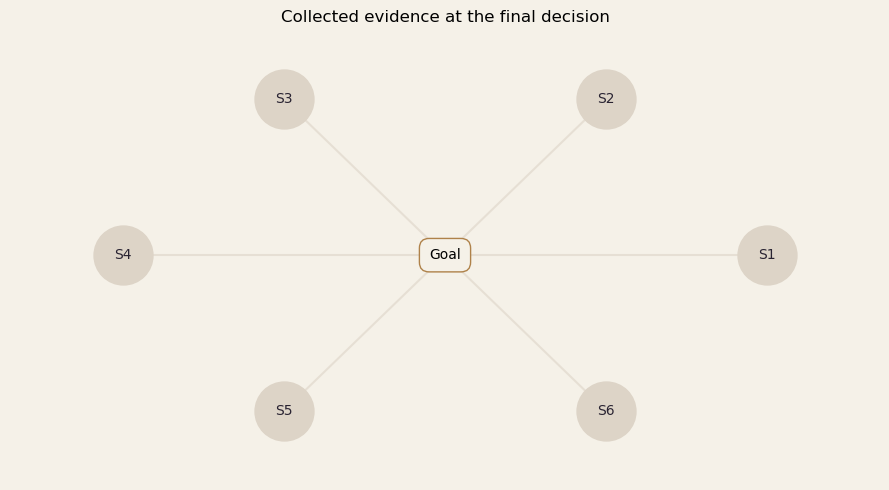

In [4]:
obs=run.observation();fig,ax=plt.subplots(figsize=(9,5));ax.axis('off')
angles=np.linspace(0,2*np.pi,6,endpoint=False)
points=np.column_stack([np.cos(angles),np.sin(angles)])
selected=set((run.artifact or {}).get('citations',[]))
for i,(x,y) in enumerate(points):
    s=obs['sources'][i];inspected=s.get('opened') or s.get('queried') or 'metadata' in s
    color='#657951' if i in selected else '#87708c' if inspected else '#ddd4c7'
    ax.plot([0,x],[0,y],color=color,alpha=.6)
    ax.scatter([x],[y],s=1800,color=color,zorder=3)
    ax.text(x,y,f'S{i+1}',ha='center',va='center',color='white' if inspected else '#292332',zorder=4)
for i,j in obs['contradictions']:
    ax.plot(points[[i,j],0],points[[i,j],1],color='#a34846',linestyle='--',alpha=.5)
ax.text(0,0,'Goal',ha='center',va='center',bbox={'facecolor':'#f5f1e8','edgecolor':'#af824a','boxstyle':'round,pad=.7'},zorder=5)
ax.set_title('Collected evidence at the final decision');ax.set_xlim(-1.35,1.35);ax.set_ylim(-1.25,1.25);plt.tight_layout();plt.show()

## 4. Export the interactive explorer

The standalone HTML animates saved reference traces and labels itself **recorded playback**. You can switch agents, cases, and budgets and inspect failures. It does not secretly retrain a controller in JavaScript. The local Python server below executes real tools one step at a time.

In [5]:
from rl_course.goallab_benchmark_demo import export
from IPython.display import HTML,FileLink
import html
preview=ARTIFACTS/'goallab-explorer.html'
export(ROOT/'projects/goallab/build-goallab/results.json',preview)
display(HTML('<iframe title="GoalLab investigation explorer" sandbox="allow-scripts" style="width:100%;height:850px;border:0" srcdoc="'+html.escape(preview.read_text(),quote=True)+'"></iframe>'))
print('Standalone explorer:',preview)

/home/shivam/anaconda3/lib/python3.12/site-packages/IPython/core/display.py:431: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Standalone explorer: /tmp/goallab-lab-_l_lfztc/goallab-explorer.html


## 5. Run the live demo locally

From the repository root in a terminal:

```bash
python -m rl_course.goallab_benchmark_demo \
  --report projects/goallab/build-goallab/results.json \
  --checkpoint projects/goallab/build-goallab/controllers-7.pt
```

Open `http://127.0.0.1:8765`. The page says **LIVE**. Each Step request executes a policy decision and its tool action; search may generate several charged branch events. Pause controls further requests. Reset starts a fresh investigation. The server is local and does not connect to real accounts.

**Change-and-explain exercise:** compare the same case at budgets 4 and 12. Before running, predict whether the agent will buy an authoritative response, inspect sources, or stop without support. Describe what the graph shows and which cost prevented a better decision. A sparse graph can be valid when a paid authority answered the question; a busy graph does not by itself demonstrate good reasoning.

## Worked budget comparison

In [6]:
rows=[]
for budget in [4,12]:
    env=train.investigate(case,'PPO',budget,policy,verifier)
    score=g.verify(case,env.artifact,env.observation())
    rows.append([budget,env.spent,env.calls,score['success'],', '.join(e['action'] for e in env.events)])
table(['Budget','Cost','Tool calls','Verified','Actions'],rows)

| Budget | Cost | Tool calls | Verified | Actions |
|---|---|---|---|---|
| 4 | 4 | 4 | False | inspect metadata 6, search, inspect metadata 2, STOP: abstain |
| 12 | 7 | 2 | True | request authoritative evidence, STOP: answer 1, confidence 50% |

## What to take away

The flagship is an evidence investigation, not an arithmetic-routing lab. Its tools expose information, its policy decides what to acquire and when to stop, and its evaluator checks the collected support. The current three-answer schema deliberately makes that boundary inspectable. It does not claim an LLM can read arbitrary documents or that a high simulated score proves production readiness.

[Return to GoalLab](../README.md) · [Read measured results](../RESULTS.md)